In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler # Z-score

# Limpeza e Pré-processamento

In [4]:
# Carregando a base de dados
df = pd.read_csv('email_phishing_data.csv')

print(f"Tamanho original do dataset: {df.shape}")
df.head()

Tamanho original do dataset: (524846, 9)


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,52,0,0,0,0,0,0
1,5,5,1,0,0,0,0,0,0
2,34,32,15,0,0,0,0,0,0
3,6,6,2,0,0,0,0,0,0
4,9,9,2,0,0,0,0,0,0


In [5]:
# Removendo duplicatas
df = df.drop_duplicates()
print(f"Tamanho após remover duplicatas: {df.shape}")

Tamanho após remover duplicatas: (205052, 9)


In [6]:
# Removendo features redundantes
colunas_redundantes = ['num_stopwords', 'num_unique_domains'] 
df = df.drop(columns=colunas_redundantes, errors='ignore')
df.head()

,num_words,num_unique_words,num_links,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140,94,0,0,0,0,0
1,5,5,0,0,0,0,0
2,34,32,0,0,0,0,0
3,6,6,0,0,0,0,0
4,9,9,0,0,0,0,0


In [7]:
# Separando features e target
X = df.drop('label', axis=1)
y = df['label']

X.head()

,num_words,num_unique_words,num_links,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,140,94,0,0,0,0
1,5,5,0,0,0,0
2,34,32,0,0,0,0
3,6,6,0,0,0,0
4,9,9,0,0,0,0


Cross-validation e Normalização

In [8]:
# Cross-validation
k = 10
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Normalização (StandardScaler = z-score)
scaler = StandardScaler()
fold = 1
dados_preparados = []

for train_index, test_index in skf.split(X, y):   
    # Separando os dados de treino e teste para o fold atual
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Normalização
    # (fit_transform) -> Calculando média e desvio padrão SOMENTE no conjunto de treino
    X_train_scaled = scaler.fit_transform(X_train)
    
    # Aplicando a Normalização (transform) no conjunto de teste
    X_test_scaled = scaler.transform(X_test)

    # Guardando os dados prontos para posterior treinamento e avaliação do modelo
    dados_preparados.append({
        'fold': fold,
        'X_train': X_train_scaled,
        'X_test': X_test_scaled,
        'y_train': y_train,
        'y_test': y_test
    })
        
    fold += 1

print(f"Pré-processamento concluído! {len(dados_preparados)} folds estão prontos para uso.")

# Vamos usar a primeira coluna (feature) como exemplo
nome_feature = X.columns[0]

# Exibindo resultado da normalizacão na feature "num_words"
print(f"\n--- Efeito da Normalização na feature: '{nome_feature}' ---")

# Estatísticas ANTES da normalização (usando o X original)
print("\n[ANTES] (Valores brutos da base original):")
print(f"Média         : {X[nome_feature].mean():.2f}")
print(f"Desvio Padrão : {X[nome_feature].std():.2f}")
print(f"Valor Máximo  : {X[nome_feature].max():.2f}") 


# Estatísticas DEPOIS da normalização (usando o Fold 1 preparado)
X_treino_norm = dados_preparados[0]['X_train']
print("\n[DEPOIS] (Valores transformados com Z-Score no Fold 1):")
print(f"Média         : {X_treino_norm[:, 0].mean():.2f}")
print(f"Desvio Padrão : {X_treino_norm[:, 0].std():.2f}")
print(f"Valor Máximo  : {X_treino_norm[:, 0].max():.2f}")


Pré-processamento concluído! 10 folds estão prontos para uso.

--- Efeito da Normalização na feature: 'num_words' ---

[ANTES] (Valores brutos da base original):
Média         : 344.90
Desvio Padrão : 5255.02
Valor Máximo  : 2339682.00

[DEPOIS] (Valores transformados com Z-Score no Fold 1):
Média         : 0.00
Desvio Padrão : 1.00
Valor Máximo  : 422.87


# KNN

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

valores_k = [1, 3, 5, 7, 9, 11, 13, 15]
metricas = ['euclidean', 'manhattan']


In [12]:
resultados = []

for metrica in metricas:
    for k in valores_k:

        accs, precs, recalls, f1s = [], [], [], []

        for pacote in dados_preparados:

            X_treino = pacote['X_train']
            y_treino = pacote['y_train']
            X_teste = pacote['X_test']
            y_teste = pacote['y_test']

            modelo = KNeighborsClassifier(n_neighbors=k, metric=metrica)
            modelo.fit(X_treino, y_treino)

            y_pred = modelo.predict(X_teste)

            accs.append(accuracy_score(y_teste, y_pred))
            precs.append(precision_score(y_teste, y_pred, average='weighted'))
            recalls.append(recall_score(y_teste, y_pred, average='weighted'))
            f1s.append(f1_score(y_teste, y_pred, average='weighted'))

        resultados.append({
            'Metrica': metrica,
            'K': k,
            'Accuracy': np.mean(accs),
            'Precision': np.mean(precs),
            'Recall': np.mean(recalls),
            'F1': np.mean(f1s),
            'Accuracy_std': np.std(accs),
            'F1_std': np.std(f1s)
        })

In [13]:
df = pd.DataFrame(resultados)

df.sort_values(
    by='F1',
    ascending=False
).head(10)

,Metrica,K,Accuracy,Precision,Recall,F1,Accuracy_std,F1_std
9,manhattan,3,0.968905,0.956252,0.968905,0.959832,0.000399,0.001021
1,euclidean,3,0.968837,0.956064,0.968837,0.959714,0.000495,0.001016
10,manhattan,5,0.970169,0.957590,0.970169,0.959350,0.000471,0.001241
2,euclidean,5,0.970061,0.957161,0.970061,0.959180,0.000427,0.001212
11,manhattan,7,0.970603,0.958895,0.970603,0.958911,0.000492,0.001255
3,euclidean,7,0.970593,0.958765,0.970593,0.958783,0.000686,0.001403
12,manhattan,9,0.970744,0.959917,0.970744,0.958395,0.000485,0.001229
4,euclidean,9,0.970671,0.959457,0.970671,0.958182,0.000432,0.001137
13,manhattan,11,0.970734,0.960424,0.970734,0.957853,0.000441,0.001058
5,euclidean,11,0.970559,0.958700,0.970559,0.957533,0.000452,0.001165


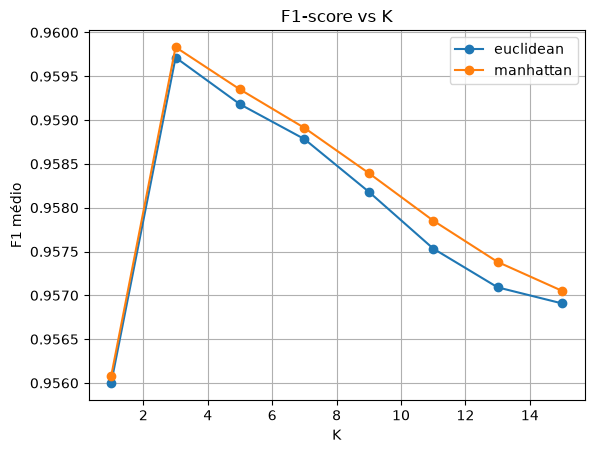

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(resultados)

plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['K'], subset['F1'], marker='o', label=metrica)

plt.title("F1-score vs K")
plt.xlabel("K")
plt.ylabel("F1 médio")
plt.legend()
plt.grid(True)
plt.show()

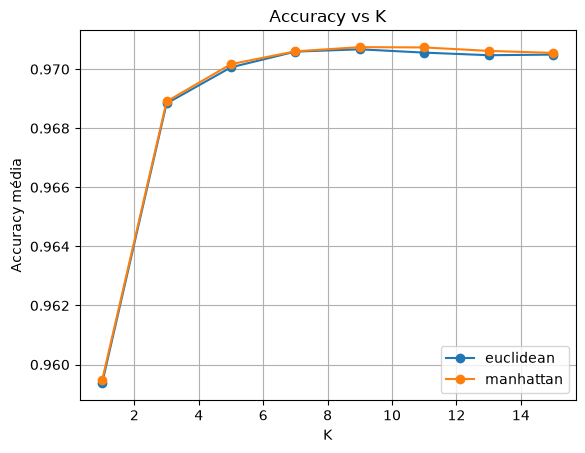

In [18]:
plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['K'], subset['Accuracy'], marker='o', label=metrica)

plt.title("Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy média")
plt.legend()
plt.grid(True)
plt.show()

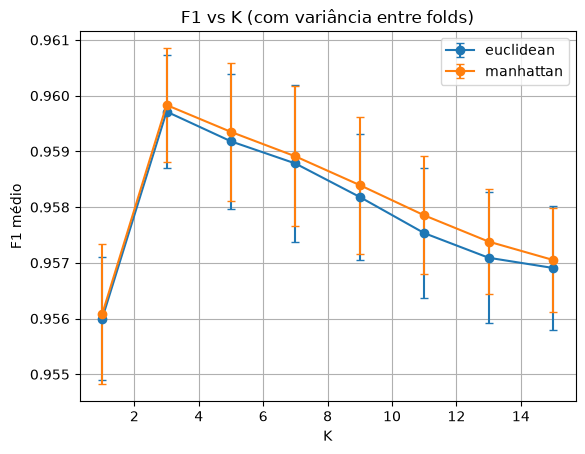

In [19]:
plt.figure()

for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]

    plt.errorbar(
        subset['K'],
        subset['F1'],
        yerr=subset['F1_std'],
        marker='o',
        capsize=3,
        label=metrica
    )

plt.title("F1 vs K (com variância entre folds)")
plt.xlabel("K")
plt.ylabel("F1 médio")
plt.legend()
plt.grid(True)
plt.show()

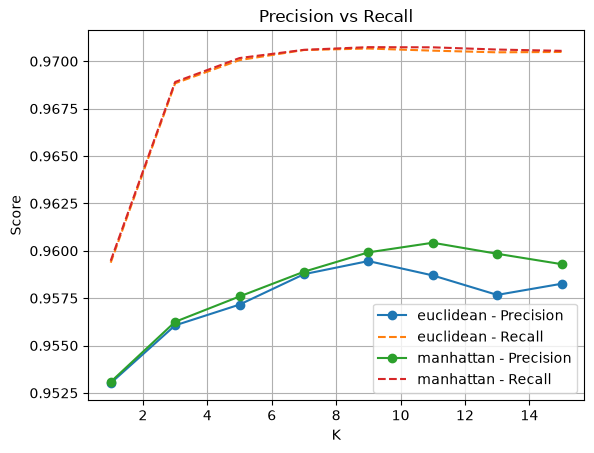

In [20]:
plt.figure()
for metrica in df['Metrica'].unique():
    subset = df[df['Metrica'] == metrica]
    plt.plot(subset['K'], subset['Precision'], marker='o', label=f"{metrica} - Precision")
    plt.plot(subset['K'], subset['Recall'], linestyle='--', label=f"{metrica} - Recall")

plt.title("Precision vs Recall")
plt.xlabel("K")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()